In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from Src.data_modules import *

import os
os.chdir("Notebooks/")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
from sklearn.utils import shuffle, resample
from sklearn.ensemble import RandomForestClassifier

# Chargement des données

In [ ]:
X, y, data = get_training_input_data_channel_parallel()

In [3]:
X = pd.read_csv("X_all_data.csv", sep=",")
y = pd.read_csv("y_all_data.csv", sep=",")

In [4]:
X

,std,var,amplitude,skewness,kurtosis,min,max,mean,median,amplitude_speed,...,cov_with_others,euclidean_distance_with_others,NMF_mode_0,NMF_mode_1,NMF_mode_2,NMF_mode_3,NMF_mode_4,NMF_mode_5,NMF_mode_6,NMF_mode_7
0,7825.555520,6.123932e+07,29688.059102,1.003226,-0.184796,-7451.310123,22236.748979,-480.055757,-3879.684711,6907.867848,...,1.298848e+08,2.534439e+05,60.758658,145.524353,0.000000,0.000000,0.000000,13.183668,0.000000,0.001347
1,3451.014189,1.190950e+07,10334.807254,0.023730,-1.433863,-7303.856154,3030.951100,-2486.790790,-2371.494282,105.911262,...,2.186959e+07,1.227805e+05,0.000000,0.000000,12.175418,0.000000,0.000000,0.000000,0.000000,7.269862
2,492.931099,2.429811e+05,1771.651573,-0.684970,-0.669198,3039.582889,4811.234461,4245.956843,4359.037392,65.751110,...,4.442941e+05,1.185094e+05,126.830619,72.440042,52.951734,39.003063,19.612547,2.806904,3.880134,8.805059
3,1464.138378,2.143701e+06,4697.576701,0.151727,-1.302688,-1501.024522,3196.552179,726.247410,576.165839,46.265269,...,4.320343e+06,5.533832e+04,52.182331,42.727429,0.000000,2.397715,0.000000,2.581118,0.928183,0.000000
4,201.662656,4.066783e+04,840.036264,0.970873,-0.181173,-2361.369121,-1521.332857,-2124.679176,-2208.791908,50.397698,...,8.180331e+04,6.490656e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261750,25523.904669,6.514697e+08,88436.246320,0.504721,-0.976549,5012.165603,93448.411924,37979.619001,32289.977212,1073.167690,...,4.207478e+07,1.158444e+06,1421.019200,1161.200942,163.915352,227.741834,84.902430,71.999322,35.089540,15.051026
261751,15533.132687,2.412782e+08,96328.259642,0.769081,1.837086,-45569.741842,50758.517800,2359.974923,4239.815744,16686.128478,...,9.160130e+07,5.082711e+05,0.000000,333.676191,111.908634,175.890510,0.000000,3.540932,0.000000,10.801796
261752,2406.259828,5.790086e+06,9016.444927,-0.140763,-1.049870,4716.024482,13732.469408,9687.546696,9730.638794,933.088027,...,-4.650309e+06,2.925163e+05,227.313020,122.009217,155.392577,81.105960,47.122991,4.547813,7.020679,33.873587
261753,780.113399,6.085769e+05,3606.611050,-1.082377,0.398272,13130.833991,16737.445041,15498.202384,15690.506107,1134.092094,...,-1.922934e+05,4.426558e+05,434.341827,254.082029,202.135559,131.491897,69.301414,11.415496,12.692468,39.133730


# Traitement des données

In [11]:
# Bootstrap : tirer un échantillon avec remplacement
bootstrap_sample_X = resample(X, n_samples=40000, replace=True)
bootstrap_sample_y = resample(y, n_samples=40000, replace=True)

X_boot = pd.concat([X, bootstrap_sample_X], axis=0)
y_boot = pd.concat([y, bootstrap_sample_y], axis=0)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.3, random_state=42)

# Modèles

In [13]:
# Initialiser le modèle Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10, n_jobs=-1, oob_score=True)

# Entraîner le modèle
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1, oob_score=True,
                       random_state=42)

# Résultats

In [14]:
y_pred = rf.predict(X_test).tolist()  # Pour une classification binaire
y_pred_train = rf.predict(X_train).tolist()

# Évaluation du modèle
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")
print("OOB Score:", rf.oob_score_)

Train Accuracy: 0.9050836063400686

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     84829
           1       0.92      0.92      0.92    126399

    accuracy                           0.91    211228
   macro avg       0.90      0.90      0.90    211228
weighted avg       0.91      0.91      0.91    211228

Test Accuracy: 0.8984612325604516

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87     36466
           1       0.92      0.91      0.91     54061

    accuracy                           0.90     90527
   macro avg       0.89      0.89      0.89     90527
weighted avg       0.90      0.90      0.90     90527

Score Kappa : 0.788974198323079
OOB Score: 0.8968839358418391


In [7]:
# Initialiser le modèle
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
# Initialiser la K-fold avec StratifiedKFold pour équilibrer les classes
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Liste pour stocker les scores kappa de chaque fold
kappa_scores = []
accuracy_scores = []

# Boucle sur les splits de K-fold
for train_index, val_index in kf.split(X_train, y_train):
    X_train_k, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_k, y_val = y_train.iloc[train_index], y_train.iloc[val_index]  # Utiliser iloc ici
    
    # Entraîner le modèle
    model.fit(X_train_k, y_train_k)
    
    # Prédictions sur l'ensemble de validation
    y_pred = model.predict(X_val)
    
    # Calculer le score kappa
    kappa = cohen_kappa_score(y_val, y_pred)
    kappa_scores.append(kappa)

    accuracy_scores.append(accuracy_score(y_val, y_pred))

# Moyenne et écart type des scores kappa
print(f"Score kappa moyen : {np.mean(kappa_scores):.4f}")
print(f"Écart type du score kappa : {np.std(kappa_scores):.4f}")

# Moyenne et écart type des scores kappa
print(f"SCore accuracy moyen : {np.mean(accuracy_scores):.4f}")
print(f"Écart type accuracy : {np.std(accuracy_scores):.4f}")

Score kappa moyen : 0.7871
Écart type du score kappa : 0.0029
SCore accuracy moyen : 0.8976
Écart type accuracy : 0.0014


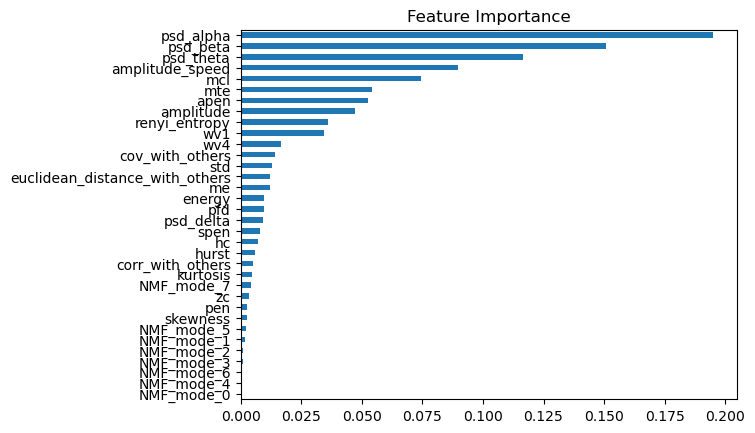

In [8]:
# Importance des features
importance = pd.Series(rf.feature_importances_, index=X_train.columns.tolist())
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

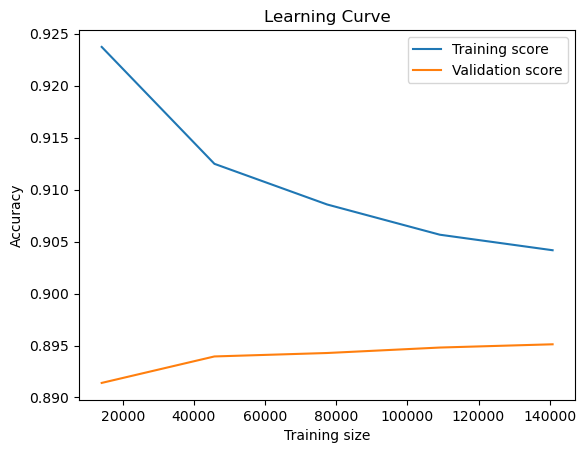

In [9]:
rf_plot = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
plot_learning_curve(rf_plot, X_train, y_train)